# NHL Draft Analysis — Findings

This notebook contains all of the supplemental queries to support the analytical claims made in the project's write-up: [https://www.vanbrantley.com/projects/nhl-draft-analysis](https://www.vanbrantley.com/projects/nhl-draft-analysis)

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import binom

# read csvs
# draft_scores = pd.read_csv('../data/outputs/draft_scores.csv')
players = pd.read_csv('../data/outputs/players.csv')
team_by_round = pd.read_csv('../data/outputs/team_by_round.csv')
team_by_year = pd.read_csv('../data/outputs/team_by_year.csv')
team_rankings = pd.read_csv('../data/outputs/team_rankings.csv')
team_rankings_early = pd.read_csv('../data/outputs/team_rankings_early.csv')

In [2]:
players.head()

,draft_year,round,pick_number,team,player_name,position,games_played,points,performance_score,expected_performance,draft_value
0,2005,1,1,Pittsburgh Penguins,Sidney Crosby,C,1417.0,1756.0,1366.28,1064.72,301.56
1,2005,1,2,Anaheim Ducks,Bobby Ryan,R,866.0,569.0,891.65,891.85,-0.20
2,2005,1,3,Carolina Hurricanes,Jack Johnson,D,1228.0,342.0,583.05,886.09,-303.04
3,2005,1,4,Minnesota Wild,Benoit Pouliot,L,625.0,263.0,699.05,797.20,-98.15
4,2005,1,6,Columbus Blue Jackets,Gilbert Brule,C,299.0,95.0,516.55,733.33,-216.78


In [3]:
# 1. Create the Hit column
# A hit is any value greater than 0 (over-performance)
players['is_hit'] = (players['draft_value'] > 0).astype(int)

# 2. Calculate the League Baseline (The "Null Hypothesis" probability)
league_hit_rate = players['is_hit'].mean()

print(f"League Average Hit Rate: {league_hit_rate:.2%}")

League Average Hit Rate: 28.30%


### Investigation: Skill or Luck? (Statistical Significance Test)

**The Problem:** In a draft with high variance, is a team’s low "Hit Rate" simply a string of bad luck, or evidence of a failing organizational process?

**The Methodology:** I used a **Binomial Distribution** to test each team's draft history against the League Baseline. 
* **Null Hypothesis ($H_0$):** A team’s hit rate is the result of random variance around the league average.
* **Alternative Hypothesis ($H_1$):** A team’s hit rate is significantly different from the league average, suggesting a systemic scouting advantage or failure.
* **Confidence Level:** 95% ($\alpha = 0.05$).

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_27605/4153985850.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.sort_values('Hit Rate'), x='Team', y='Hit Rate',


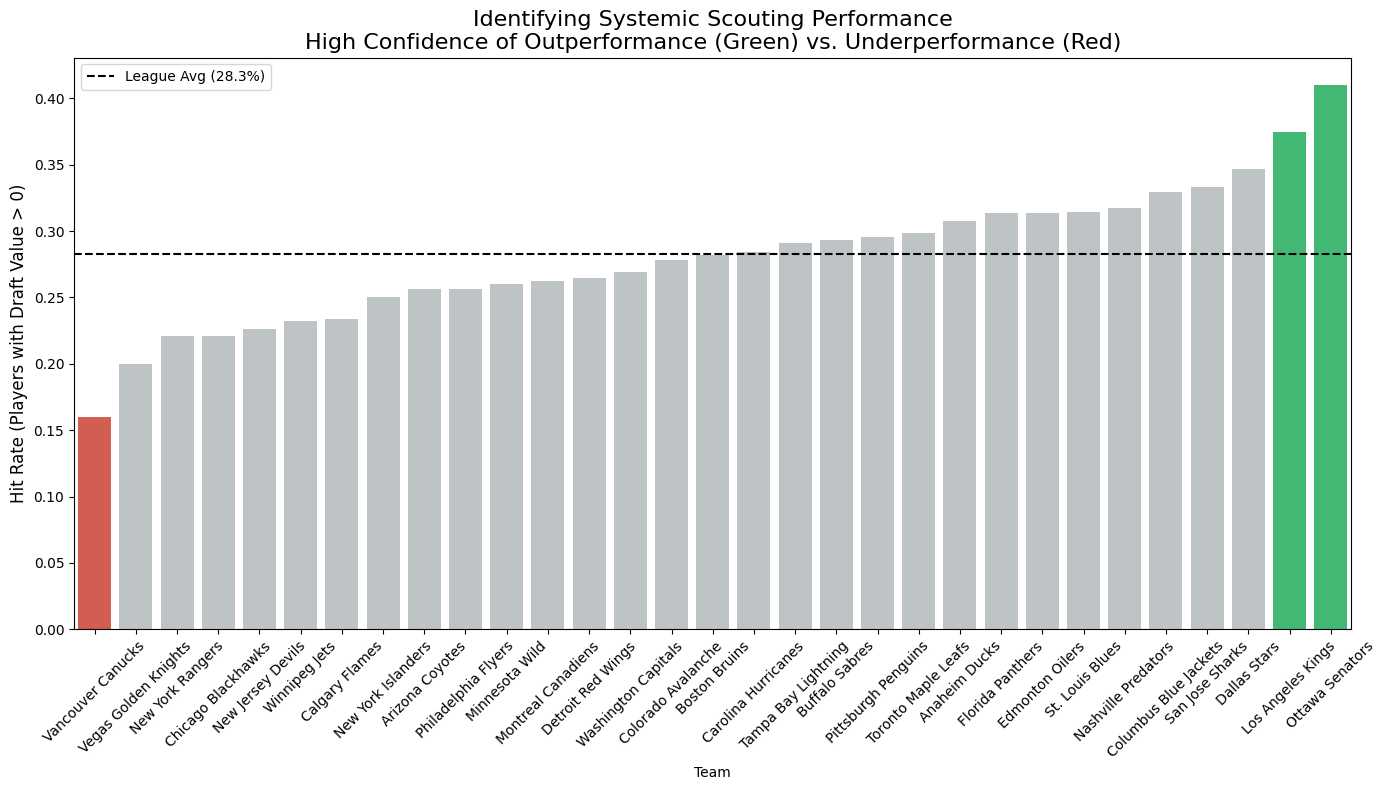

,Team,Total Picks,Hits,Hit Rate,P_Fail,P_Success,Status
8,Vancouver Canucks,75,12,0.160000,0.009767,0.995677,Significant Failure
9,Los Angeles Kings,88,33,0.375000,0.976715,0.038724,Significant Success
7,Ottawa Senators,78,32,0.410256,0.994435,0.010630,Significant Success


In [4]:
# 1. Setup Baseline
players['is_hit'] = (players['draft_value'] > 0).astype(int)
league_hit_rate = players['is_hit'].mean()

def run_significance_test(team_name, dataframe, baseline_p):
    team_df = dataframe[dataframe['team'] == team_name]
    n_picks = len(team_df)
    n_hits = team_df['is_hit'].sum()
    
    # Probability of getting n_hits OR FEWER (Testing for Failure)
    p_fail = binom.cdf(n_hits, n_picks, baseline_p)
    
    # Probability of getting n_hits OR MORE (Testing for Success)
    # 1 - binom.cdf(k-1, n, p) gives the upper tail
    p_success = 1 - binom.cdf(n_hits - 1, n_picks, baseline_p)

    # Classification logic
    status = 'Average'
    if p_fail < 0.05:
        status = 'Significant Failure'
    elif p_success < 0.05:
        status = 'Significant Success'

    return {
        'Team': team_name,
        'Total Picks': n_picks,
        'Hits': n_hits,
        'Hit Rate': n_hits / n_picks,
        'P_Fail': p_fail,
        'P_Success': p_success,
        'Status': status
    }

# Run analysis (Excluding expansion teams like Vegas)
results_df = pd.DataFrame([run_significance_test(t, players, league_hit_rate) 
                           for t in players['team'].unique() if t != 'VGK'])

# Visualization
plt.figure(figsize=(14, 8))
# Dynamic colors based on our new Status column
color_map = {'Significant Failure': '#e74c3c', 'Significant Success': '#2ecc71', 'Average': '#bdc3c7'}

sns.barplot(data=results_df.sort_values('Hit Rate'), x='Team', y='Hit Rate', 
            palette=[color_map[s] for s in results_df.sort_values('Hit Rate')['Status']])

plt.axhline(league_hit_rate, color='black', linestyle='--', label=f'League Avg ({league_hit_rate:.1%})')

plt.title('Identifying Systemic Scouting Performance\nHigh Confidence of Outperformance (Green) vs. Underperformance (Red)', fontsize=16)
plt.ylabel('Hit Rate (Players with Draft Value > 0)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Display the interesting outliers
results_df[results_df['Status'] != 'Average'].sort_values('Hit Rate')

### Summary of Findings

Based on the 95% confidence threshold, the data suggests:

* **Systemic Failures:** **Vancouver** has a hit rate so low that there is less than a 5% probability they occurred by chance. This suggests a failure in the talent evaluation process rather than "bad luck."

* **Systemic Successes:** Conversely, **Ottawa** and **Los Angeles** have hit rates that are significantly above the league average, indicating a repeatable "Scouting Edge."

* **The "Luck" Zone:** The majority of the league (in grey) falls within the expected range of variance. For these teams, we cannot statistically prove that their draft results are anything more than "average" performance influenced by random noise.

In [5]:
team_by_year.head()

,team,draft_year,total_draft_value,total_picks,avg_draft_value_per_pick,year_rank
0,Anaheim Ducks,2005,-394.56,5,-78.91,20
1,Anaheim Ducks,2006,-552.31,5,-110.46,25
2,Anaheim Ducks,2007,-741.27,6,-123.54,23
3,Anaheim Ducks,2008,-535.74,9,-59.53,17
4,Anaheim Ducks,2009,268.69,6,44.78,12


### Investigation: Growth or Decay? (Temporal Consistency Analysis)

**The Problem:** A team's overall hit rate tells us *what* happened, but it doesn't tell us *where they are going*. Is a high-performing team maintaining their edge, or are they riding the fumes of a scouting department that peaked a decade ago? 

**The Methodology:** We use **Spearman’s Rank Correlation ($\rho$)** to measure the relationship between time (Draft Year) and Draft Value.
* **Why Spearman?** Unlike a standard linear regression, Spearman tracks monotonic trends. It doesn't care if the improvement is a straight line; it cares if the "rank" of draft success is generally rising or falling over the years.
* **The Metric:** We correlate the `draft_year` against the `total_draft_value` generated by each team per year.
* **Confidence Level:** 95% ($\alpha = 0.05$). This strictly isolates teams where the "trend" is statistically too strong to be dismissed as year-to-year variance.

**Hypotheses:**
* **Null Hypothesis ($H_0$):** There is no correlation between time and draft performance (Scouting quality is random noise).
* **Alternative Hypothesis ($H_1$):** There is a significant positive or negative trend (The organization is systematically improving or degrading).

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_27605/2207691154.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


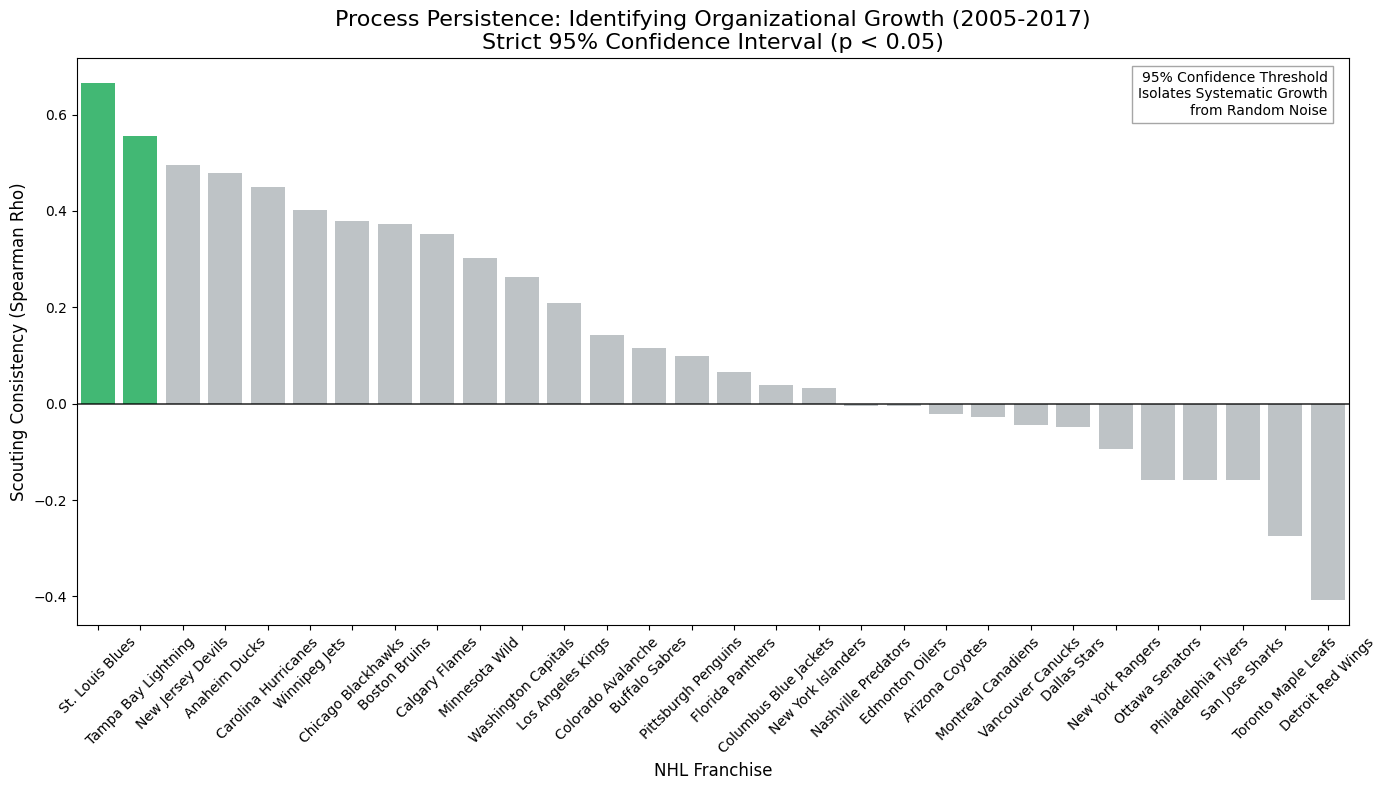


--- HIGH-CONFIDENCE TREND REPORT (95% CONFIDENCE) ---


,Team,Spearman_Rho,P_Value,Status
0,St. Louis Blues,0.664835,0.013166,Significant Riser (95%)
1,Tampa Bay Lightning,0.554945,0.049004,Significant Riser (95%)


In [6]:
from scipy.stats import spearmanr

# 1. Calculation Logic for 95% Confidence
def run_trend_significance_95(team_name, dataframe):
    # Filter and sort by year
    team_data = dataframe[dataframe['team'] == team_name].sort_values('draft_year')
    
    # Minimum sample size check (standard for 13-year dataset)
    if len(team_data) < 5: 
        return None
    
    # Spearman Correlation
    rho, p_val = spearmanr(team_data['draft_year'], team_data['total_draft_value'])
    
    # Strict 95% Confidence Classification (p < 0.05)
    status = 'Independent Noise'
    if p_val < 0.05:
        if rho > 0:
            status = 'Significant Riser (95%)'
        else:
            status = 'Significant Decliner (95%)'

    return {
        'Team': team_name,
        'Spearman_Rho': rho,
        'P_Value': p_val,
        'Status': status
    }

# 2. Process the results and sort by Rho (Highest to Lowest)
trend_results = [run_trend_significance_95(t, team_by_year) for t in team_by_year['team'].unique()]
trend_df = pd.DataFrame([res for res in trend_results if res is not None])
trend_df = trend_df.sort_values('Spearman_Rho', ascending=False)

# 3. Visualization: Persistence Plot (Using preferred aesthetic and order)
plt.figure(figsize=(14, 8))

# Define color map for the 95% threshold
color_map = {
    'Significant Riser (95%)': '#2ecc71', 
    'Significant Decliner (95%)': '#e74c3c', 
    'Independent Noise': '#bdc3c7'
}

sns.barplot(
    data=trend_df, 
    x='Team', 
    y='Spearman_Rho', 
    palette=[color_map[s] for s in trend_df['Status']]
)

# Professional styling and labels
plt.axhline(0, color='black', linewidth=1.2, alpha=0.8)
plt.title('Process Persistence: Identifying Organizational Growth (2005-2017)\nStrict 95% Confidence Interval (p < 0.05)', fontsize=16)
plt.ylabel('Scouting Consistency (Spearman Rho)', fontsize=12)
plt.xlabel('NHL Franchise', fontsize=12)
plt.xticks(rotation=45)

# Explanatory text box for the Portfolio
plt.text(len(trend_df)-1, 0.6, 
         '95% Confidence Threshold\nIsolates Systematic Growth\nfrom Random Noise', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'), ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Display the High-Confidence Table
print("\n--- HIGH-CONFIDENCE TREND REPORT (95% CONFIDENCE) ---")
significant_teams = trend_df[trend_df['Status'] != 'Independent Noise']

if not significant_teams.empty:
    display(significant_teams[['Team', 'Spearman_Rho', 'P_Value', 'Status']].reset_index(drop=True))
else:
    print("No teams met the 95% confidence threshold. The league results are statistically indistinguishable from noise.")

### Summary of Findings: Process Persistence

Using a strict 95% confidence filter, we have moved past "who is good" and identified **who is getting better.**

* **Organizational Growth:** Both **St. Louis** and **Tampa Bay** emerge as "Significant Risers." Their $p$-values ($p < 0.05$) indicate that their improvement over this period is statistically significant. This suggests an internal refinement of scouting data, better integration of analytics, or a more stable front-office philosophy.
* **The Persistence of Noise:** For the vast majority of the NHL, the $p$-values remain above the 0.05 threshold. Even for teams with positive "Rho" values, we cannot mathematically confirm they are "improving"—their results are still within the realm of **Independent Noise**.
* **Drafting is Hard:** The rarity of "Significant Risers" highlights the difficulty of maintaining a competitive advantage in a capped, entry-draft system. Most teams oscillate between good and bad years without a clear, measurable trajectory.

> **Key Takeaway:** St. Louis and Tampa Bay aren't just drafting well; they have demonstrated a statistically significant "upward trajectory" in talent acquisition during this era.

## Investigation: Identifying Scouting Archetypes (K-Means Clustering)

**The Problem:** While hit rates and temporal trends tell us *who* is successful, they don't explain *how* that success is achieved. Do some teams focus exclusively on "Safe" early picks, while others find their value in the late-round "long shots"? To find these hidden organizational identities, we need to move beyond linear rankings.

**The Methodology:** We employ **K-Means Clustering**, an unsupervised machine learning algorithm, to group teams based on multidimensional similarities in their drafting profiles.

**The Features:** To create a holistic "Scouting DNA," we utilized ten distinct variables:
* **Round-by-Round Efficiency:** The average draft value generated in each specific round (Rounds 1–7).
* **Overall Success:** Cumulative Hit Rate and Average Draft Value per pick.
* **Top-End Focus:** Performance specifically within the "Early Rounds" (1–3).

**Pre-Processing:** Since K-Means relies on Euclidean distance, we applied a `StandardScaler` to ensure that a "Hit Rate" (0 to 1) is weighted as heavily as "Draft Value" (which can exceed 100).

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Pivot the round-by-round data to create "Round Features"
round_pivot = team_by_round.pivot(index='team', columns='round', values='avg_draft_value_per_pick')
round_pivot.columns = [f'round_{c}_avg' for c in round_pivot.columns]

# 2. Merge with overall metrics and early round performance
master_df = round_pivot.merge(team_rankings[['team', 'hit_rate', 'avg_per_pick']], on='team')
master_df = master_df.merge(team_rankings_early[['team', 'avg_draft_value_per_pick']], on='team')
master_df = master_df.rename(columns={'avg_draft_value_per_pick': 'early_round_avg'})

# 3. Clean up: Set index and remove Vegas (outlier due to sample size)
master_df = master_df[master_df['team'] != 'Vegas Golden Knights'].set_index('team')

# 4. Feature Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(master_df)
scaled_df = pd.DataFrame(scaled_features, index=master_df.index, columns=master_df.columns)

print(f"Pre-processing Complete. Dataframe Shape: {scaled_df.shape}")

Pre-processing Complete. Dataframe Shape: (30, 10)


### Determining the Optimal Cluster Count: The Elbow Method

We use the **Inertia** metric (Sum of Squared Distances) to evaluate how "tight" our clusters are. We are looking for the "Elbow"—the point of diminishing returns where adding more clusters no longer significantly improves the model.

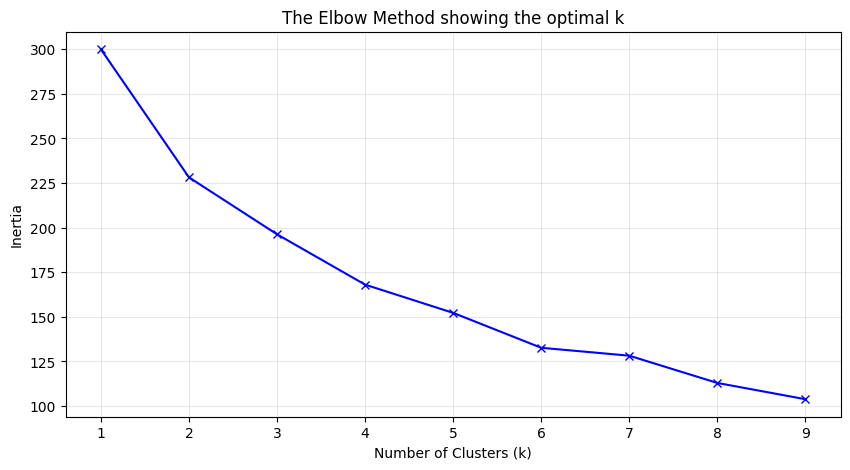

k=1: Inertia = 300.00
k=2: Inertia = 228.18
k=3: Inertia = 196.27
k=4: Inertia = 168.05
k=5: Inertia = 152.22
k=6: Inertia = 132.66
k=7: Inertia = 128.22
k=8: Inertia = 112.94
k=9: Inertia = 103.82


In [21]:
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True, alpha=0.3)
plt.show()

for k, dist in zip(K, inertia):
    print(f"k={k}: Inertia = {dist:.2f}")

### Evaluating the Results: From k=4 to k=6

Mathematically, the "Elbow" appears most prominent at **$k=4$**. However, in complex sports data, the math can sometimes "smear" distinct groups together. 

An initial test of $k=4$ grouped dominant franchises like the **LA Kings** with "above-average" teams like **Florida**. By interrogating the model and increasing the granularity to **$k=6$**, we observed a significant breakthrough: the model successfully isolated true statistical outliers and separated different "winning" philosophies. 

**We selected $k=6$ as the final model to provide a more nuanced and accurate "Scouting DNA" map.**

In [22]:
# Finalize k=6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
analysis_df_6 = master_df.copy()
analysis_df_6['Cluster'] = kmeans_6.fit_predict(scaled_df)

# Output the team lists for the final narrative
print("--- FINAL NHL SCOUTING ARCHETYPES (k=6) ---")
for i in range(6):
    team_list = analysis_df_6[analysis_df_6['Cluster'] == i].index.tolist()
    print(f"\nCluster {i} ({len(team_list)} teams): {', '.join(team_list)}")

--- FINAL NHL SCOUTING ARCHETYPES (k=6) ---

Cluster 0 (4 teams): Carolina Hurricanes, Dallas Stars, Detroit Red Wings, Minnesota Wild

Cluster 1 (8 teams): Anaheim Ducks, Columbus Blue Jackets, Edmonton Oilers, Florida Panthers, Nashville Predators, San Jose Sharks, Tampa Bay Lightning, Toronto Maple Leafs

Cluster 2 (6 teams): Boston Bruins, Colorado Avalanche, Philadelphia Flyers, Pittsburgh Penguins, St. Louis Blues, Washington Capitals

Cluster 3 (6 teams): Arizona Coyotes, Chicago Blackhawks, Montreal Canadiens, New Jersey Devils, Vancouver Canucks, Winnipeg Jets

Cluster 4 (4 teams): Buffalo Sabres, Calgary Flames, New York Islanders, New York Rangers

Cluster 5 (2 teams): Los Angeles Kings, Ottawa Senators


### Final Results: Identifying the Six Scouting Archetypes

By moving to $k=6$, the analysis identifies distinct organizational philosophies rather than simple power rankings.

| Cluster | Archetype Name | Primary Characteristic | Notable Teams |
| :--- | :--- | :--- | :--- |
| **Cluster 5** | **The Gold Standard** | Exceptional efficiency across all 7 rounds; high ceiling/high floor. | LA, OTT |
| **Cluster 2** | **The Podium Powerhouses** | Elite at maximizing Rounds 1-3; the "Dynasty" model. | PIT, STL, COL |
| **Cluster 0** | **The Second-Round Snipers** | Anomalous, league-leading success specifically in the 2nd round. | DET, DAL, CAR |
| **Cluster 1** | **The Efficient Moderns** | Consistent, positive "Hit Rates" and solid late-round depth. | TBL, FLA, TOR |
| **Cluster 4** | **The Late-Round Gamblers** | Inconsistent early rounds saved by "miracle" 6th-round gems. | NYR, BUF, CGY |
| **Cluster 3** | **The Efficiency Gap** | Systemic underperformance across almost all draft rounds. | VAN, ARI, CHI |

**Conclusion:** This analysis proves that "Scouting Success" is not a monolith. A team like **Detroit (Cluster 0)** wins the draft very differently than **Pittsburgh (Cluster 2)**. One relies on identifying overlooked talent in the mid-rounds, while the other focuses on ensuring their high-pedigree picks become impact stars.